# BÀI TẬP LỚN MACHINE LEARNING
## Notebook 03: Phân tích Tương quan & Quan hệ Đa biến

**Người thực hiện:** Nhân / Person 4  
**Mục tiêu:** Phân tích quan hệ giữa các biến số, sàng lọc đa cộng tuyến, so sánh đặc trưng theo biến mục tiêu `deposit` và kiểm tra nguy cơ rò rỉ dữ liệu.

> Lưu ý: tương quan chỉ mô tả mối liên hệ trong tập dữ liệu, không chứng minh quan hệ nhân quả.


### 1. Khởi tạo, đọc dữ liệu và xác định biến phân tích
Chỉ các đại lượng số có ý nghĩa mới được dùng cho Pearson/Spearman. Các biến phân loại danh nghĩa không được gán mã số tùy ý để diễn giải tương quan. Riêng `pdays = -1` là mã “chưa từng liên hệ”, nên bị tách khỏi phần số ngày thực.


In [1]:
from itertools import combinations
from pathlib import Path

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency, pointbiserialr
from sklearn.linear_model import LinearRegression

ROOT = next(
    (path for path in [Path.cwd(), *Path.cwd().parents]
     if (path / 'data' / 'raw' / 'bank.csv').is_file()),
    None
)
if ROOT is None:
    raise FileNotFoundError('Không tìm thấy data/raw/bank.csv.')

DATA_PATH = ROOT / 'data' / 'raw' / 'bank.csv'
FIGURE_DIR = ROOT / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
target_col = 'deposit'
numeric_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
expected_cols = [
    'age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
    'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
    'previous', 'poutcome', target_col
]
assert df.columns.tolist() == expected_cols, 'Schema không khớp với bank.csv.'
assert set(df[target_col].unique()) == {'no', 'yes'}, 'Nhãn deposit không hợp lệ.'

target_binary = df[target_col].map({'no': 0, 'yes': 1})
relationship_data = df[numeric_cols].copy()
relationship_data['pdays'] = relationship_data['pdays'].where(relationship_data['pdays'] >= 0)
relationship_data = relationship_data.rename(columns={'pdays': 'pdays (>= 0)'})

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

print(f'Kích thước dữ liệu: {df.shape[0]:,} dòng × {df.shape[1]} cột')
print(f'Số bản ghi đã từng liên hệ dùng cho pdays: {relationship_data["pdays (>= 0)"].notna().sum():,}')


Kích thước dữ liệu: 11,162 dòng × 17 cột
Số bản ghi đã từng liên hệ dùng cho pdays: 2,838


### 2. Ma trận tương quan Pearson và Spearman
Pearson được dùng để mô tả quan hệ tuyến tính; Spearman dùng thứ hạng nên ít nhạy hơn với phân bố lệch và ngoại lai. Các ô liên quan `pdays (>= 0)` được tính theo cặp trên 2.838 khách hàng đã từng được liên hệ.


Ma trận Pearson:


,age,balance,day,duration,campaign,pdays (>= 0),previous
age,1.000,0.112,-0.001,0.000,-0.005,-0.063,0.020
balance,0.112,1.000,0.010,0.022,-0.014,-0.063,0.031
day,-0.001,0.010,1.000,-0.019,0.137,-0.032,-0.059
duration,0.000,0.022,-0.019,1.000,-0.042,0.038,-0.027
campaign,-0.005,-0.014,0.137,-0.042,1.000,0.040,-0.050
pdays (>= 0),-0.063,-0.063,-0.032,0.038,0.040,1.000,-0.012
previous,0.020,0.031,-0.059,-0.027,-0.050,-0.012,1.000


Ma trận Spearman:


,age,balance,day,duration,campaign,pdays (>= 0),previous
age,1.000,0.106,-0.001,-0.014,0.019,-0.023,0.012
balance,0.106,1.000,0.000,0.058,-0.039,-0.114,0.097
day,-0.001,0.000,1.000,-0.044,0.110,-0.021,-0.085
duration,-0.014,0.058,-0.044,1.000,-0.054,0.022,0.018
campaign,0.019,-0.039,0.110,-0.054,1.000,0.074,-0.118
pdays (>= 0),-0.023,-0.114,-0.021,0.022,0.074,1.000,-0.121
previous,0.012,0.097,-0.085,0.018,-0.118,-0.121,1.000


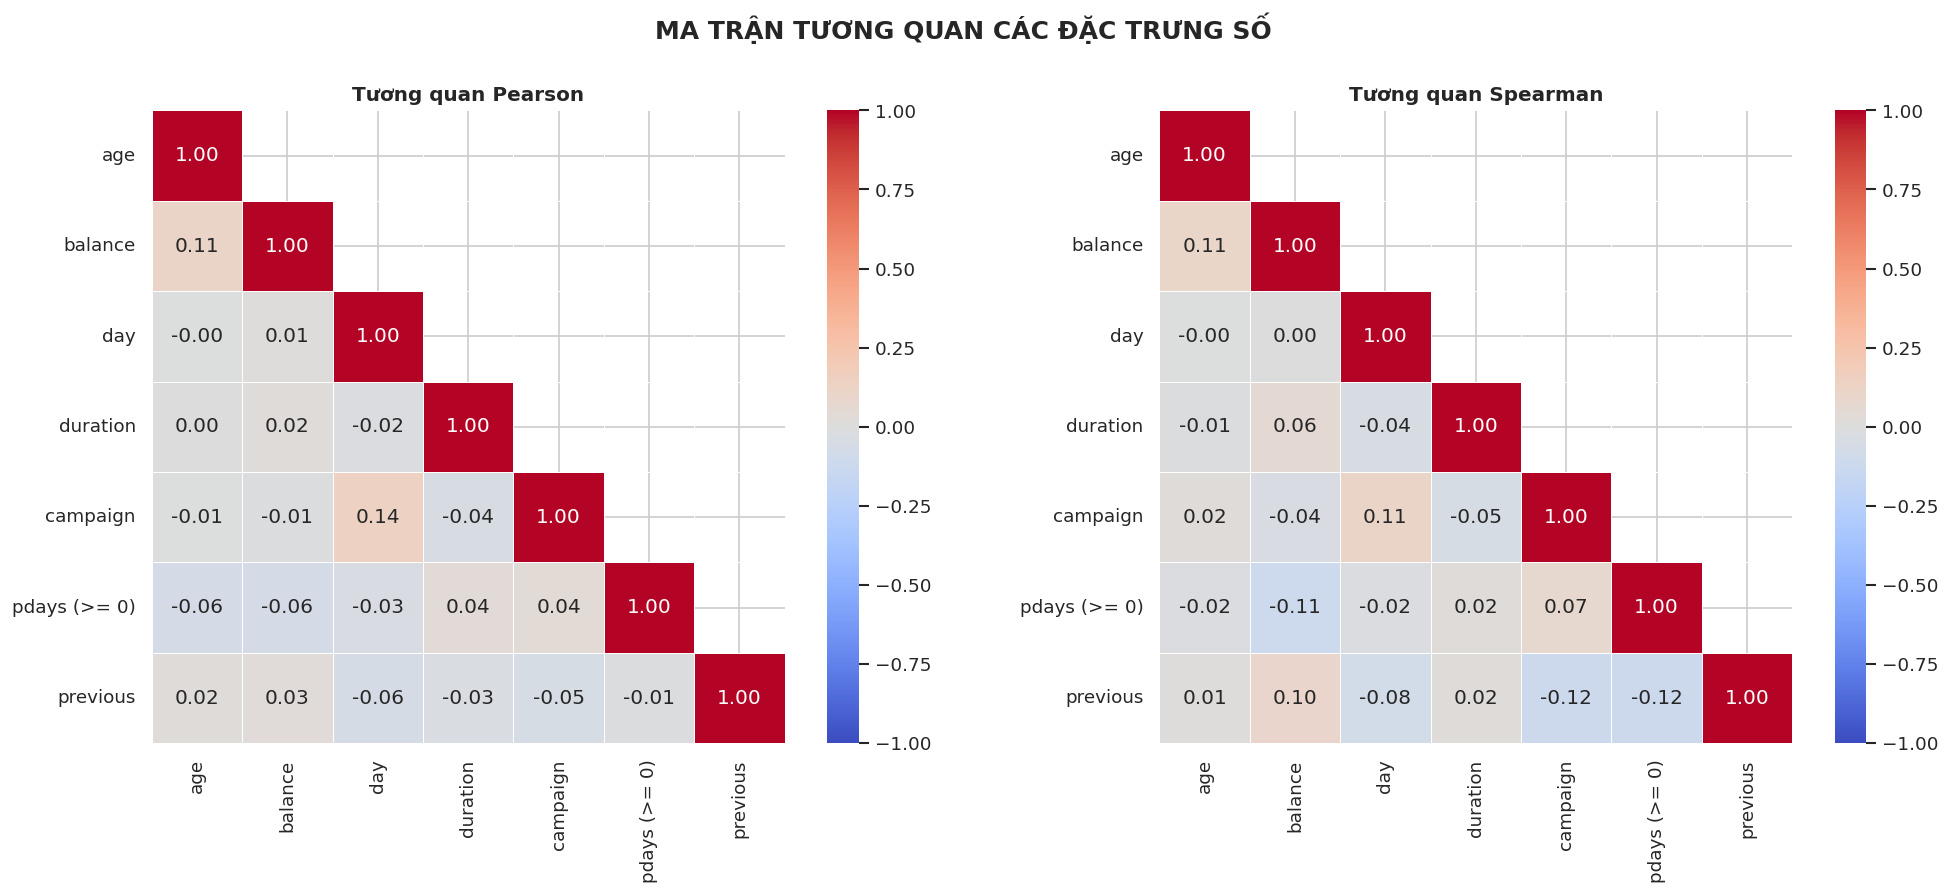

Đã lưu tại: E:\Downloads\BTL_ML_git\figures\03_correlation_matrix.png


In [2]:
pearson_corr = relationship_data.corr(method='pearson')
spearman_corr = relationship_data.corr(method='spearman')

print('Ma trận Pearson:')
display(pearson_corr.round(3))
print('Ma trận Spearman:')
display(spearman_corr.round(3))

mask = np.triu(np.ones_like(pearson_corr, dtype=bool), k=1)
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
for ax, matrix, title in [
    (axes[0], pearson_corr, 'Tương quan Pearson'),
    (axes[1], spearman_corr, 'Tương quan Spearman'),
]:
    sns.heatmap(
        matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
        vmin=-1, vmax=1, center=0, square=True, linewidths=0.5, ax=ax
    )
    ax.set_title(title, fontweight='bold')

plt.suptitle('MA TRẬN TƯƠNG QUAN CÁC ĐẶC TRƯNG SỐ', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
correlation_path = FIGURE_DIR / '03_correlation_matrix.png'
plt.savefig(correlation_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Đã lưu tại: {correlation_path}')


### Nhận xét tương quan giữa các đặc trưng số

- Không có cặp đặc trưng số nào tương quan mạnh. Pearson lớn nhất theo trị tuyệt đối là `day` – `campaign` (khoảng 0,137); Spearman lớn nhất khoảng 0,121 giữa `previous` và `pdays` trong nhóm đã từng liên hệ.
- `age` và `balance` có tương quan dương yếu (Pearson khoảng 0,112).
- Dấu và độ lớn giữa Pearson/Spearman có khác nhẹ do `balance`, `campaign`, `previous` và `pdays` có phân bố lệch.
- Các kết quả chỉ cho biết quan hệ thống kê; không được diễn giải thành nguyên nhân.


### 3. Sàng lọc cặp tương quan mạnh và đa cộng tuyến
Ngưỡng `|r| >= 0,8` và `VIF > 5` dưới đây chỉ là **heuristic sàng lọc**, không phải ngưỡng khoa học phổ quát. `pdays` không được đưa vào VIF toàn bộ dữ liệu vì `-1` là sentinel; biến này đã được xem riêng trong ma trận tương quan.


In [3]:
correlation_threshold = 0.8
strong_rows = []
for method, matrix in [('Pearson', pearson_corr), ('Spearman', spearman_corr)]:
    for left, right in combinations(matrix.columns, 2):
        value = matrix.loc[left, right]
        if abs(value) >= correlation_threshold:
            strong_rows.append({
                'Phương pháp': method, 'Biến 1': left, 'Biến 2': right,
                'Hệ số': value, 'Heuristic': '|r| >= 0.8'
            })
strong_pairs = pd.DataFrame(strong_rows)
if strong_pairs.empty:
    print('Không có cặp đặc trưng nào vượt heuristic |r| >= 0.8.')
else:
    display(strong_pairs.round(3))

vif_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'previous']
vif_rows = []
for col in vif_cols:
    predictors = df[vif_cols].drop(columns=col)
    r_squared = LinearRegression().fit(predictors, df[col]).score(predictors, df[col])
    vif_rows.append({
        'Đặc trưng': col, 'R² từ các biến còn lại': r_squared,
        'VIF': 1 / (1 - r_squared), 'VIF > 5': 1 / (1 - r_squared) > 5
    })
vif_table = pd.DataFrame(vif_rows).sort_values('VIF', ascending=False)
display(vif_table.round(3))


Không có cặp đặc trưng nào vượt heuristic |r| >= 0.8.


,Đặc trưng,R² từ các biến còn lại,VIF,VIF > 5
4,campaign,0.022,1.023,False
2,day,0.022,1.022,False
1,balance,0.014,1.014,False
0,age,0.013,1.013,False
5,previous,0.007,1.007,False
3,duration,0.003,1.003,False


Kết quả VIF chỉ dao động khoảng 1,00–1,02. Vì vậy, chưa có dấu hiệu đa cộng tuyến đáng kể giữa các đặc trưng số được sàng lọc.


### 4. Quan hệ giữa đặc trưng số và biến mục tiêu
Vì `deposit` có hai lớp, point-biserial correlation được dùng cho biến số. Bảng đồng thời trình bày trung bình, trung vị theo lớp và standardized mean difference (SMD) để tránh chỉ dựa vào p-value.


,Đặc trưng,Số mẫu,Point-biserial r,p-value,Mean (no),Mean (yes),Median (no),Median (yes),SMD
3,duration,11162,0.452,0.0,223.130,537.295,163.0,426.0,1.015
6,pdays (>= 0),2838,-0.144,0.0,229.925,192.522,208.0,181.0,-0.309
5,previous,11162,0.140,0.0,0.528,1.170,0.0,0.0,0.283
4,campaign,11162,-0.128,0.0,2.839,2.141,2.0,2.0,-0.259
1,balance,11162,0.081,0.0,1280.227,1804.268,414.0,733.0,0.163
2,day,11162,-0.056,0.0,16.108,15.158,16.0,15.0,-0.113
0,age,11162,0.035,0.0,40.837,41.670,39.0,38.0,0.070


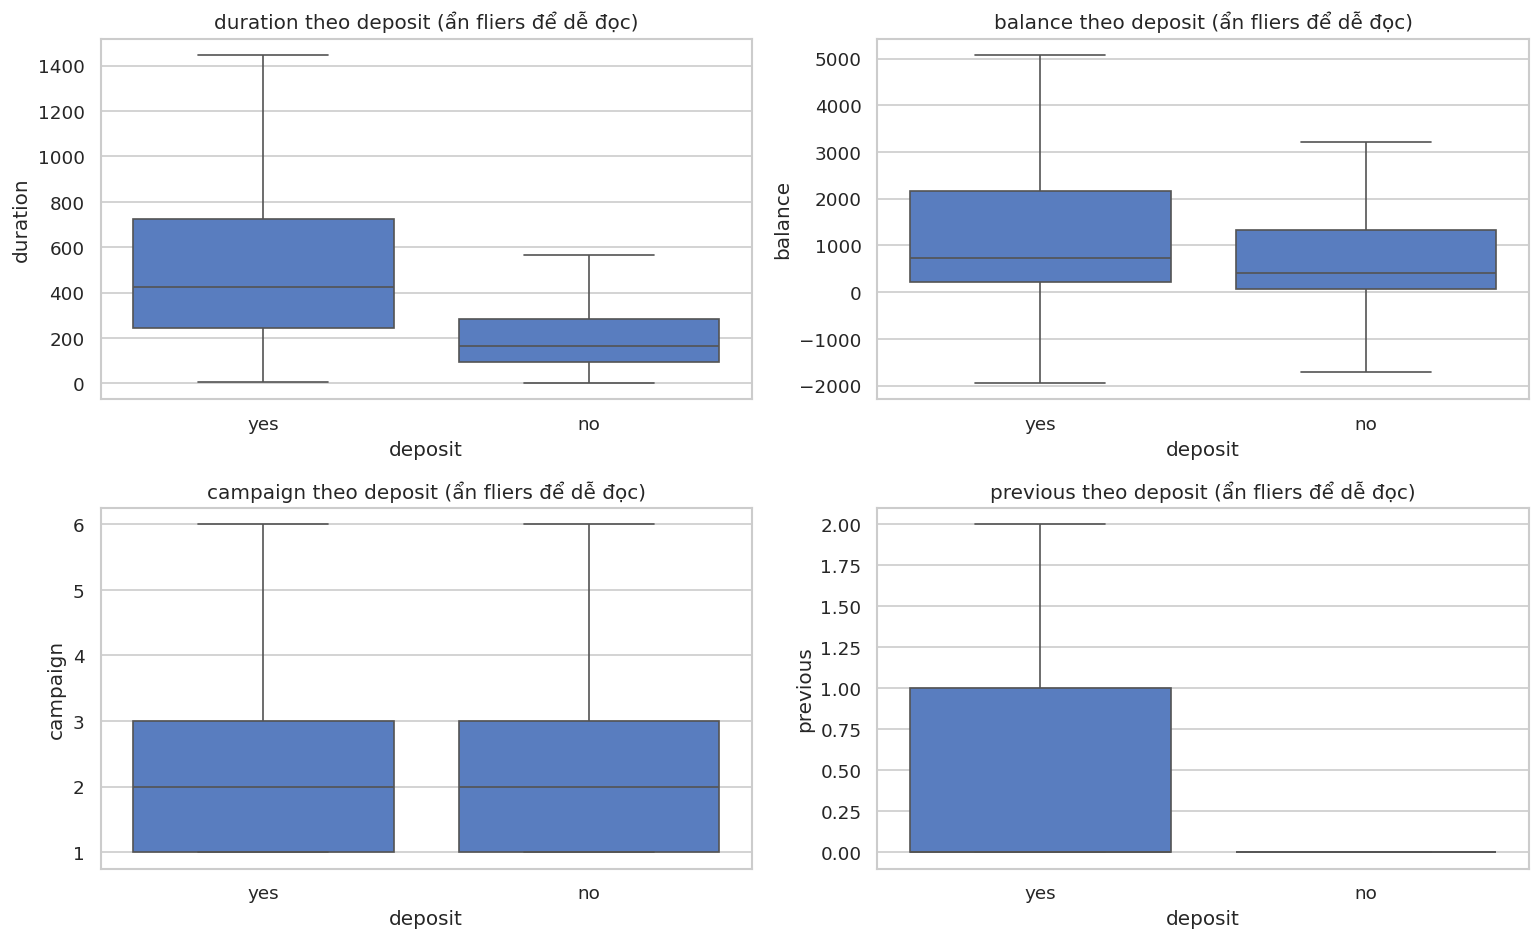

In [4]:
target_rows = []
for col in ['age', 'balance', 'day', 'duration', 'campaign', 'previous']:
    values_no = df.loc[df[target_col] == 'no', col]
    values_yes = df.loc[df[target_col] == 'yes', col]
    r_value, p_value = pointbiserialr(target_binary, df[col])
    pooled_sd = np.sqrt(
        ((len(values_no) - 1) * values_no.var() + (len(values_yes) - 1) * values_yes.var())
        / (len(values_no) + len(values_yes) - 2)
    )
    target_rows.append({
        'Đặc trưng': col, 'Số mẫu': len(df), 'Point-biserial r': r_value,
        'p-value': p_value, 'Mean (no)': values_no.mean(), 'Mean (yes)': values_yes.mean(),
        'Median (no)': values_no.median(), 'Median (yes)': values_yes.median(),
        'SMD': (values_yes.mean() - values_no.mean()) / pooled_sd
    })

contacted = df['pdays'] >= 0
values_no = df.loc[contacted & df[target_col].eq('no'), 'pdays']
values_yes = df.loc[contacted & df[target_col].eq('yes'), 'pdays']
r_value, p_value = pointbiserialr(target_binary[contacted], df.loc[contacted, 'pdays'])
pooled_sd = np.sqrt(
    ((len(values_no) - 1) * values_no.var() + (len(values_yes) - 1) * values_yes.var())
    / (len(values_no) + len(values_yes) - 2)
)
target_rows.append({
    'Đặc trưng': 'pdays (>= 0)', 'Số mẫu': int(contacted.sum()),
    'Point-biserial r': r_value, 'p-value': p_value,
    'Mean (no)': values_no.mean(), 'Mean (yes)': values_yes.mean(),
    'Median (no)': values_no.median(), 'Median (yes)': values_yes.median(),
    'SMD': (values_yes.mean() - values_no.mean()) / pooled_sd
})

target_relationships = (
    pd.DataFrame(target_rows)
    .assign(abs_r=lambda table: table['Point-biserial r'].abs())
    .sort_values('abs_r', ascending=False)
    .drop(columns='abs_r')
)
display(target_relationships.round(3))

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.flatten(), ['duration', 'balance', 'campaign', 'previous']):
    sns.boxplot(data=df, x=target_col, y=col, showfliers=False, ax=ax)
    ax.set_title(f'{col} theo deposit (ẩn fliers để dễ đọc)')
plt.tight_layout()
plt.show()


### Nhận xét quan hệ đặc trưng – mục tiêu

- `duration` nổi bật nhất: point-biserial `r ≈ 0,452`, trung bình 223 giây ở lớp `no` và 537 giây ở lớp `yes`, SMD khoảng 1,015. Đây là liên hệ mạnh về mặt mô tả nhưng cũng là biến cần kiểm tra leakage theo thời điểm dự đoán.
- Trong nhóm đã từng liên hệ, `pdays` có liên hệ âm yếu-vừa (`r ≈ -0,144`): nhóm `yes` có trung bình khoảng 193 ngày, thấp hơn nhóm `no` khoảng 230 ngày.
- `previous` liên hệ dương (`r ≈ 0,140`), còn `campaign` liên hệ âm (`r ≈ -0,128`).
- `balance`, `day`, `age` có quan hệ biên yếu hơn. Các kết quả không chứng minh rằng thay đổi các biến này sẽ gây ra đăng ký tiền gửi.


### 5. Quan hệ của biến phân loại với mục tiêu
Các biến danh nghĩa được đánh giá bằng Cramér's V và tỷ lệ `deposit = yes`, không dùng Pearson trên mã category.


In [5]:
def cramers_v(feature, target):
    contingency = pd.crosstab(feature, target)
    chi2 = chi2_contingency(contingency, correction=False)[0]
    n = contingency.to_numpy().sum()
    denominator = min(contingency.shape[0] - 1, contingency.shape[1] - 1)
    return np.sqrt((chi2 / n) / denominator)

categorical_cols = [
    'job', 'marital', 'education', 'default', 'housing',
    'loan', 'contact', 'month', 'poutcome'
]
categorical_rows = []
for col in categorical_cols:
    yes_rates = df.groupby(col, observed=True)[target_col].apply(lambda values: values.eq('yes').mean())
    categorical_rows.append({
        'Đặc trưng': col, 'Cramér V': cramers_v(df[col], df[target_col]),
        'Nhóm có tỷ lệ yes thấp nhất': yes_rates.idxmin(),
        'Tỷ lệ yes thấp nhất': yes_rates.min(),
        'Nhóm có tỷ lệ yes cao nhất': yes_rates.idxmax(),
        'Tỷ lệ yes cao nhất': yes_rates.max(),
    })
categorical_relationships = (
    pd.DataFrame(categorical_rows)
    .sort_values('Cramér V', ascending=False)
)
display(categorical_relationships.round(3))

previously_contacted_rates = pd.crosstab(contacted, df[target_col], normalize='index')
previously_contacted_rates.index = ['Chưa từng liên hệ', 'Đã từng liên hệ']
display(previously_contacted_rates.round(3))


,Đặc trưng,Cramér V,Nhóm có tỷ lệ yes thấp nhất,Tỷ lệ yes thấp nhất,Nhóm có tỷ lệ yes cao nhất,Tỷ lệ yes cao nhất
7,month,0.306,may,0.328,dec,0.909
8,poutcome,0.300,unknown,0.407,success,0.913
6,contact,0.257,unknown,0.226,cellular,0.543
4,housing,0.204,yes,0.366,no,0.570
0,job,0.184,blue-collar,0.364,student,0.747
5,loan,0.111,yes,0.332,no,0.495
2,education,0.105,primary,0.394,tertiary,0.541
1,marital,0.099,married,0.434,single,0.543
3,default,0.041,yes,0.310,no,0.476


deposit,no,yes
Chưa từng liên hệ,0.593,0.407
Đã từng liên hệ,0.329,0.671


`month` (`V ≈ 0,306`), `poutcome` (`V ≈ 0,300`) và `contact` (`V ≈ 0,257`) có mức liên hệ lớn nhất trong nhóm biến phân loại. Đặc biệt, `poutcome = success` có tỷ lệ `yes` khoảng 91,3%, còn khách hàng đã từng được liên hệ có tỷ lệ `yes` khoảng 67,1%. Đây là các dấu hiệu cần kiểm tra về thời điểm và nguồn tạo dữ liệu, không phải bằng chứng nhân quả.


### 6. Kiểm tra rò rỉ dữ liệu và biến đáng ngờ


In [6]:
direct_target_copies = [
    col for col in df.columns if col != target_col
    and df[col].astype(str).equals(df[target_col].astype(str))
]
poutcome_success_rate = df.loc[df['poutcome'].eq('success'), target_col].eq('yes').mean()
leakage_audit = pd.DataFrame([
    {
        'Kiểm tra': 'Cột định danh',
        'Kết quả': 'Không có cột ID rõ ràng',
        'Đánh giá': 'Giảm nguy cơ ghi nhớ ID, nhưng không thể group theo khách hàng để kiểm tra lặp thực thể.'
    },
    {
        'Kiểm tra': 'Bản ghi trùng hoàn toàn / trùng predictor',
        'Kết quả': f'{df.duplicated().sum()} / {df.drop(columns=target_col).duplicated().sum()}',
        'Đánh giá': 'Không phát hiện duplicate hoặc cặp predictor giống nhau mang nhãn khác.'
    },
    {
        'Kiểm tra': 'Cột sao chép trực tiếp target',
        'Kết quả': str(direct_target_copies),
        'Đánh giá': 'Không phát hiện cột nào trùng hoàn toàn với deposit.'
    },
    {
        'Kiểm tra': 'duration',
        'Kết quả': f'r = {target_relationships.set_index("Đặc trưng").loc["duration", "Point-biserial r"]:.3f}',
        'Đánh giá': 'Chỉ biết sau/khi cuộc gọi diễn ra; là leakage nếu mục tiêu là dự đoán trước cuộc gọi.'
    },
    {
        'Kiểm tra': 'poutcome = success',
        'Kết quả': f'Tỷ lệ yes = {poutcome_success_rate:.3%}',
        'Đánh giá': 'Kết quả chiến dịch trước, không phải nhãn hiện tại; vẫn phải xác nhận được ghi nhận trước dự đoán.'
    },
    {
        'Kiểm tra': 'pdays sentinel và previous',
        'Kết quả': f'{df["pdays"].eq(-1).sum():,} dòng pdays=-1; {df["previous"].eq(0).sum():,} dòng previous=0',
        'Đánh giá': 'Hai biến cùng mã hóa lịch sử chưa liên hệ; cần tránh diễn giải -1 như khoảng cách số.'
    },
])
display(leakage_audit)


,Kiểm tra,Kết quả,Đánh giá
0,Cột định danh,Không có cột ID rõ ràng,"Giảm nguy cơ ghi nhớ ID, nhưng không thể group..."
1,Bản ghi trùng hoàn toàn / trùng predictor,0 / 0,Không phát hiện duplicate hoặc cặp predictor g...
2,Cột sao chép trực tiếp target,[],Không phát hiện cột nào trùng hoàn toàn với de...
3,duration,r = 0.452,Chỉ biết sau/khi cuộc gọi diễn ra; là leakage ...
4,poutcome = success,Tỷ lệ yes = 91.317%,"Kết quả chiến dịch trước, không phải nhãn hiện..."
5,pdays sentinel và previous,"8,324 dòng pdays=-1; 8,324 dòng previous=0",Hai biến cùng mã hóa lịch sử chưa liên hệ; cần...


## 2.3. Phân tích tương quan và quan hệ đa biến

Phân tích Pearson và Spearman được thực hiện trên bảy biến số, trong đó `pdays = -1` được xem là mã sentinel và loại khỏi phép tính số ngày. Không có cặp đặc trưng nào vượt heuristic sàng lọc `|r| >= 0,8`; hệ số lớn nhất chỉ khoảng 0,137 theo Pearson. VIF của các biến số dùng trên toàn bộ dữ liệu nằm trong khoảng 1,00–1,02, do đó chưa có dấu hiệu đa cộng tuyến đáng kể.

Đối với biến mục tiêu, `duration` có quan hệ nổi bật nhất (`r ≈ 0,452`, SMD ≈ 1,015), tiếp theo là `pdays` trong nhóm đã từng liên hệ (`r ≈ -0,144`), `previous` (`r ≈ 0,140`) và `campaign` (`r ≈ -0,128`). Trong nhóm biến phân loại, `month`, `poutcome` và `contact` có Cramér's V lần lượt khoảng 0,306; 0,300 và 0,257. Những hệ số này chỉ phản ánh association trong mẫu, không cho phép kết luận nhân quả.

Kiểm tra leakage không phát hiện cột ID, bản ghi trùng predictor hoặc cột sao chép trực tiếp `deposit`. Tuy nhiên, `duration` chỉ được biết trong/sau cuộc gọi nên sẽ gây rò rỉ nếu bài toán yêu cầu dự đoán trước khi liên hệ. `poutcome = success` có tỷ lệ đăng ký khoảng 91,3% nhưng là kết quả của chiến dịch trước; biến này chỉ hợp lệ khi chắc chắn có sẵn trước thời điểm dự đoán hiện tại.


### Kết luận

- Không phát hiện cặp số tương quan mạnh hoặc đa cộng tuyến đáng kể.
- `duration` là biến liên hệ với mục tiêu mạnh nhất nhưng đồng thời là rủi ro leakage phụ thuộc thời điểm dự đoán.
- `poutcome`, trạng thái đã liên hệ trước, `month` và `contact` cần được giữ đúng ngữ nghĩa nghiệp vụ khi đánh giá mô hình.
- Không mã hóa category danh nghĩa thành ID số để diễn giải Pearson, và không có kết luận nhân quả nào được đưa ra.
